See document for the technical difficulties encountered... 

In [2]:
# Standard libraries
import os
import numpy as np
import pandas as pd

# Image handling
from PIL import Image
import matplotlib.pyplot as plt

# # HuggingFace / model loading
import torch
# from transformers import AutoProcessor, AutoModelForVision2Seq

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Import Kaggle dataset
!kaggle datasets download -d ahemateja19bec1025/traffic-sign-dataset-classification

Data visualization: want to visualize a few images with their ground truth labels from labels.csv in the dataset

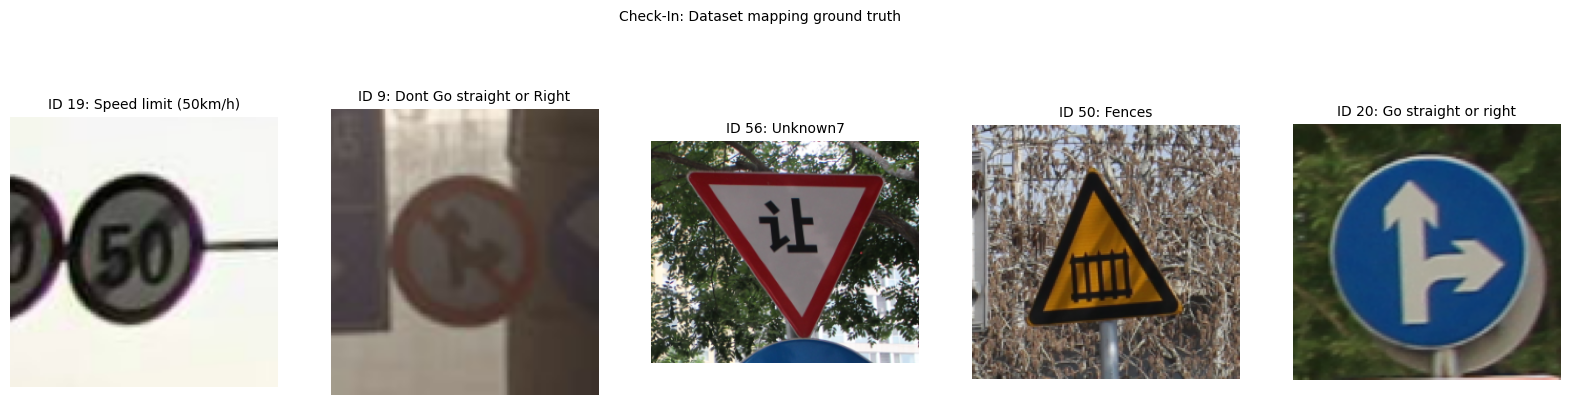

In [3]:
labels = '/mnt/home/fllin/cv153_final_project/traffic_data/labels.csv'
data = '/mnt/home/fllin/cv153_final_project/traffic_data/traffic_Data/DATA'

#read in the labels data file
df = pd.read_csv(labels)

# sample 5 classes just to see
sample = df.sample(5)

fig, axes = plt.subplots(1,5, figsize=(20, 5))
for i, (idx, row) in enumerate(sample.iterrows()):
    class_id = row['ClassId']
    label_name = row['Name']
    
    class_folder = os.path.join(data, str(class_id))
    
    if os.path.exists(class_folder) and len(os.listdir(class_folder)) > 0:
        first_img = os.listdir(class_folder)[0]
        img_path = os.path.join(class_folder, first_img)
        
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"ID {class_id}: {label_name}", fontsize=10)
        axes[i].axis('off')
    else:
        axes[i].set_title(f"ID {class_id}: Not Found")
        axes[i].axis('off')

plt.suptitle("Check-In: Dataset mapping ground truth", fontsize=10)
plt.show()

In [4]:
# gemma3 pipeline -- 4b
from transformers import pipeline
import torch

pipe = pipeline(
    "image-text-to-text",
    model="google/gemma-3-4b-it",
    device="cuda",
    torch_dtype=torch.bfloat16
)

# prompt for sign labeling
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What is written on this sign?"}
        ]
    }
]

# tokenize
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(model.device)


output = pipe(messages, max_new_tokens=50)
print(output[0]["generated_text"][-1]["content"])


ModuleNotFoundError: Could not import module 'pipeline'. Are this object's requirements defined correctly?

In [5]:
# gemma 4
from transformers import AutoProcessor, AutoModelForCausalLM, AutoModelForImageTextToText
model_id = "google/gemma-4-E4B-it"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="cuda"
).eval()

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What is written on this sign?"}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    add_generation_prompt=True,
).to(model.device)
with torch.inference_mode():
    output = model.generate(**inputs, max_new_tokens=50)

answer = processor.decode(output[0], skip_special_tokens=True)
print(answer)


ModuleNotFoundError: Could not import module 'AutoProcessor'. Are this object's requirements defined correctly?